In [1]:
!hostname -f

euclid.uibk.ac.at


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
from cosmopower import cosmopower_NN



2025-04-14 14:45:53.431952: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-14 14:45:53.479837: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-14 14:45:53.481746: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-14 14:45:54.216817: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# Example of emulator training

This notebook shows how to train an emulator for $\langle N_{ap} M_{ap} \rangle$ as a function of Halo Occupation Distribution parameters. The emulator has a fixed architecture (that is probably not optimal).

## Preliminaries
First, we check if a GPU is available (speeds up training) and set the random seed for the initialization of the model

In [7]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

NameError: name 'tf' is not defined

In [3]:
# setting the seed for reproducibility
np.random.seed(9721)
tf.random.set_seed(9721)

## Get training, validation and testing data

Now we read in out training data and split it for validation and testing

In [4]:
# Get test/training split

N_total=6000 # Total samples
f_val = 0.15 # We use 15% of samples as validation samples
f_test=0.15 # We use 15% of samples as test samples 
f_train=1-f_val-f_test

# Calculate test and train sample counts
N_test = int(f_test * N_total)
N_train = int(f_train * N_total)
N_val = int(f_val * N_total)

# Generate indices
indices = np.arange(N_total)
np.random.shuffle(indices)

testing_indices=indices[:N_test]
validation_indices = indices[N_test:N_test+N_val]
training_indices = indices[N_test+N_val:N_total]

print(f"Number of test samples is {len(testing_indices)}, should be {N_test}")
print(f"Number of validation samples is {len(validation_indices)}, should be {N_val}")

print(f"Number of train samples is {len(training_indices)}, should be {N_train}")


Number of test samples is 900, should be 900
Number of validation samples is 900, should be 900
Number of train samples is 4200, should be 4200


Text(0, 0.5, 'Sample index')

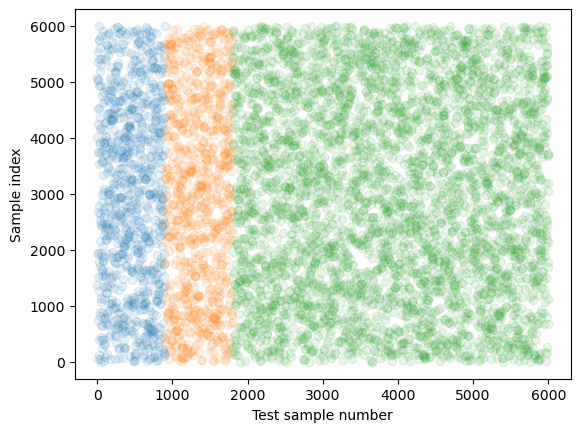

In [5]:
# Plot of test_indices and train_indices

plt.scatter(range(N_test), testing_indices, alpha=0.1)
plt.scatter(np.arange(N_val)+N_test, validation_indices, alpha=0.1)
plt.scatter(np.arange(N_train)+N_test+N_val, training_indices, alpha=0.1)

plt.xlabel('Test sample number')
plt.ylabel('Sample index')

### Parameter files

Now we read in the parameter values. These are for now Halo Occupation Distribution parameters, but could be also cosmological parameter

In [6]:
# training parameters

params_fn="../Data/sobol_sequence_hod_params_MN.json"


# Read in
with open(params_fn, "r") as json_file:
    samples = json.load(json_file)

## Convert lists back to numpy arrays
training_parameters = {key: (np.array(value)[training_indices]) for key, value in samples.items()}
validation_parameters = {key: (np.array(value)[validation_indices]) for key, value in samples.items()}

testing_parameters = {key: (np.array(value)[testing_indices]) for key, value in samples.items()}


In [7]:
print('number of training samples:', len(training_parameters['logMth']), '. Should be', N_train)
print('number of validation samples:', len(validation_parameters['logMth']), '. Should be', N_val)

print('number of test samples:', len(testing_parameters['logMth']), '. Should be', N_test)


number of training samples: 4200 . Should be 4200
number of validation samples: 900 . Should be 900
number of test samples: 900 . Should be 900


### Feature files
Now we read in the model values (=features) which correspond to the read in parameters. We need to be sure that they are ordered in the same way as the parameter values!

In [8]:
# feature files

features_fn="../Data/HOD_Models_Euclid_nz_MN.json"

# Read in
with open(features_fn, "r") as json_file:
    samples = json.load(json_file)

training_features={}
testing_features={}
validation_features={}

# Aperture radii
training_features['modes']=samples['thetas_rad']
testing_features['modes']=samples['thetas_rad']
validation_features['modes']=samples['thetas_rad']




N_modes is the length of one model vector (i.e. one feature). In our case these correspond to the aperture radii.

In [9]:
N_modes=len(training_features['modes'])
print('number of aperture radii [rad]: ', len(training_features['modes']))

number of aperture radii [rad]:  10


We are taking the natural logarithm of the features, because then they are in a smaller dynamical range. This makes training easier

In [10]:
# Values

training_features_values=[]
for k in samples.keys():
    if k != 'thetas_rad':
        training_features_values.append(np.log(samples[k])) # Take natural logarithm of measurements => Better for training

training_features['features']=np.array(training_features_values)[training_indices]
testing_features['features']=np.array(training_features_values)[testing_indices]
validation_features['features']=np.array(training_features_values)[validation_indices]


In [11]:
print(f"Shape of training features: {training_features['features'].shape}. Should be ({N_train}, {N_modes})")
print(f"Shape of testing features: {testing_features['features'].shape}. Should be ({N_test}, {N_modes})")
print(f"Shape of validation features: {validation_features['features'].shape}. Should be ({N_val}, {N_modes})")




Shape of training features: (4200, 10). Should be (4200, 10)
Shape of testing features: (900, 10). Should be (900, 10)
Shape of validation features: (900, 10). Should be (900, 10)


Now, for a cross check we plot the mean of the training, testing and validation data sets. These should all look roughly the same, otherwise we have selected strange test and validation sets.

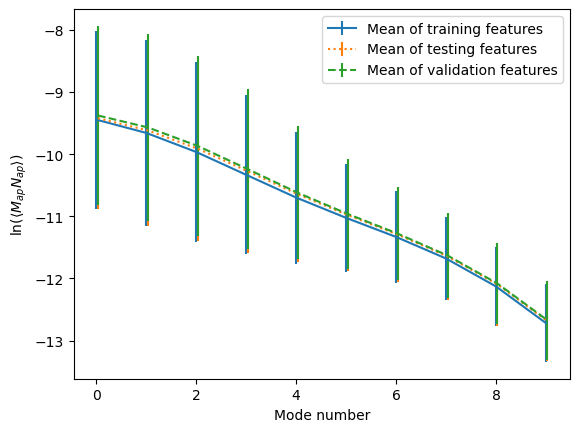

In [12]:
plt.errorbar(range(len(training_features['modes'])),np.mean(training_features['features'], axis=0), 
             yerr=np.std(training_features['features'], axis=0), label='Mean of training features')
plt.errorbar(np.arange(len(testing_features['modes']))+0.03,np.mean(testing_features['features'], axis=0), ls=':', 
             yerr=np.std(testing_features['features'], axis=0), label='Mean of testing features')
plt.errorbar(np.arange(len(validation_features['modes']))+0.03,np.mean(validation_features['features'], axis=0), ls='--', 
             yerr=np.std(validation_features['features'], axis=0), label='Mean of validation features')

plt.ylabel(r"$\ln(\langle M_{ap} N_{ap}\rangle)$")
plt.xlabel(r"Mode number")
plt.legend()

### Some renamings

For use with ```cosmopower``` we are renaming the parameters and  and writing them from dicts to lists

In [13]:
# parameter names
model_parameters = [k for k in training_parameters.keys()]

# modes (=aperture radii)
modes=training_features['modes']

# features (=<NapMap>)
train_features=training_features['features']
test_features=testing_features['features']
val_features=validation_features['features']

### rescaling

We are rescaling the features by the mean and standard deviation of the training features. Then, they are all scattering by 1 and have a mean value of 0.

In [14]:

processing_vectors = {'mean':np.mean(train_features,axis=0), 'sigma':np.std(train_features,axis=0)}

def preprocessing(features,processing_vectors):
    return (features-processing_vectors['mean'])/processing_vectors['sigma']

def postprocessing(features,processing_vectors):
    return features*processing_vectors['sigma'] + processing_vectors['mean']


train_features_rescaled=preprocessing(train_features, processing_vectors)
test_features_rescaled=preprocessing(test_features, processing_vectors)
val_features_rescaled=preprocessing(val_features, processing_vectors)


## Convert numpy arrays to lists for JSON serialization and save the values of the processing vectors
serializable_processing_vectors = {key: value.tolist() for key, value in processing_vectors.items()}
processing_out="../Emulators/NM_processing_vectors.json"
with open(processing_out, "w") as json_file:
    json.dump(serializable_processing_vectors, json_file)

We plot the rescaled features to check if the rescaling worked

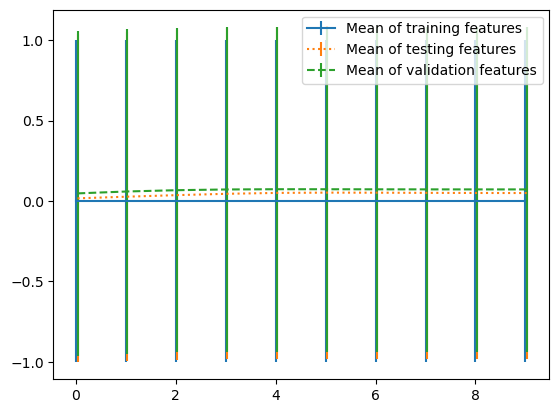

In [15]:
plt.errorbar(range(len(modes)),np.mean(train_features_rescaled, axis=0), 
             yerr=np.std(train_features_rescaled, axis=0), label='Mean of training features')
plt.errorbar(np.arange(len(modes))+0.03,np.mean(test_features_rescaled, axis=0), ls=':', 
             yerr=np.std(test_features_rescaled, axis=0), label='Mean of testing features')
plt.errorbar(np.arange(len(modes))+0.03,np.mean(val_features_rescaled, axis=0), ls='--', 
             yerr=np.std(val_features_rescaled, axis=0), label='Mean of validation features')

plt.legend()

## Training

Now we are ready to train the emulator!

## Define the Neural Network
We define the neural network with the following function

In [16]:

# instantiate NN class
cp_nn = cosmopower_NN(parameters=model_parameters, 
                      modes=modes, 
                      n_hidden = [512, 512, 512, 512], # 4 hidden layers, each with 512 nodes
                      verbose=True, # useful to understand the different steps in initialisation and training
                      )




Initialized cosmopower_NN model, 
mapping 6 input parameters to 10 output modes, 
using 4 hidden layers, 
with [512, 512, 512, 512] nodes, respectively. 



2025-03-07 09:34:24.630869: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-07 09:34:24.632117: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Set training hyperparameters
We set some hyperparameters: How many features are processed in one step (batch_size), how fast the gradient descent should happen (learning_Rate), after how many steps without improvement the learning should stop (patience_values) and what is the maximal number of learning steps (max_epochs).

We also set where to save the emulator

In [17]:

batch_sizes=[1024, 1024, 1024, 1024, 1024, 1024]
learning_rates=[1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
patience_values=[100, 100, 1000, 1000, 1000, 1000]
max_epochs=[1000, 1000, 10000, 10000, 10000, 10000]
model_filename="../Emulators/NM"


We need to do some conversions for TensorFlow

In [18]:

# Convert to tensors for use in TensorFlow
training_parameters_tf = tf.convert_to_tensor(
    np.column_stack([training_parameters[key] for key in training_parameters]), dtype=tf.float32
)
validation_parameters_tf = tf.convert_to_tensor(
    np.column_stack([validation_parameters[key] for key in validation_parameters]), dtype=tf.float32
)

training_features_tf = tf.convert_to_tensor(train_features_rescaled, dtype=tf.float32)
validation_features_tf = tf.convert_to_tensor(val_features_rescaled, dtype=tf.float32)

# Dataset for training
training_data = tf.data.Dataset.from_tensor_slices((training_parameters_tf, training_features_tf)).shuffle(len(training_indices)).batch(1024)

all_training_loss=[]
all_validation_loss=[]


### Actual training
Now lets run the training! In each step, the training loss ```loss``` is saved, this is what the training aims to minimize. We also save the validation loss ```loss```. This describes how accurate the emulator is on the validation set and we can use this to decide if the NN is under or overfitting.

In [19]:

# Training loop with manual loss logging
for i in range(len(learning_rates)):  # Loop over learning steps
    print(f"Starting learning step {i + 1} with lr={learning_rates[i]}, batch_size={batch_sizes[i]}")

    # Set learning rate
    cp_nn.optimizer.lr = learning_rates[i]


    # Reset early stopping and best loss tracking
    best_loss = np.inf
    early_stopping_counter = 0

    for epoch in range(max_epochs[i]):
        # Train for one epoch
        for batch_parameters, batch_features in training_data:
            loss = cp_nn.training_step(batch_parameters, batch_features)

        # Calculate validation loss
        validation_loss = cp_nn.compute_loss(validation_parameters_tf, validation_features_tf).numpy()

        # Log training and validation loss
        if epoch%100 ==0:
            print(f"Epoch {epoch + 1}/{max_epochs[i]}: Training Loss = {loss.numpy():.4f}, Validation Loss = {validation_loss:.4f}")
        all_training_loss.append(loss.numpy())
        all_validation_loss.append(validation_loss)

        # Check early stopping
        if validation_loss < best_loss:
            best_loss = validation_loss
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        if early_stopping_counter >= patience_values[i]:
            print(f"Early stopping triggered at epoch {epoch + 1} with best validation loss = {best_loss:.4f}")
            break

    # Update the model parameters before saving
    cp_nn.update_emulator_parameters()

    # Save the model to a file
    cp_nn.save(model_filename)
    
    print(f"Completed learning step {i + 1}. Best validation loss = {best_loss:.4f}")


Starting learning step 1 with lr=0.01, batch_size=1024
Epoch 1/1000: Training Loss = 1.0528, Validation Loss = 1.0113
Epoch 101/1000: Training Loss = 0.1827, Validation Loss = 0.1906
Epoch 201/1000: Training Loss = 0.1144, Validation Loss = 0.1500
Early stopping triggered at epoch 293 with best validation loss = 0.0692
Completed learning step 1. Best validation loss = 0.0692
Starting learning step 2 with lr=0.001, batch_size=1024
Epoch 1/1000: Training Loss = 0.0632, Validation Loss = 0.0813
Epoch 101/1000: Training Loss = 0.0270, Validation Loss = 0.0287
Epoch 201/1000: Training Loss = 0.0218, Validation Loss = 0.0214
Epoch 301/1000: Training Loss = 0.0282, Validation Loss = 0.0333
Epoch 401/1000: Training Loss = 0.0214, Validation Loss = 0.0314
Epoch 501/1000: Training Loss = 0.0174, Validation Loss = 0.0236
Early stopping triggered at epoch 581 with best validation loss = 0.0154
Completed learning step 2. Best validation loss = 0.0154
Starting learning step 3 with lr=0.0001, batch_s

## Plots for convergence and accuracy


### Loss curves
One diagnostic are the loss curves, showing the training and validation loss as function of training epoch. The training loss should decrease with time, as this is what is minimized. At the same time, the validation loss should also decrease, as the network will perform better on the validation set as well. After some time though, the validation loss might stay stagnant or increase, while the training loss continues to decrease. In this case the network is overfitting on the training data set

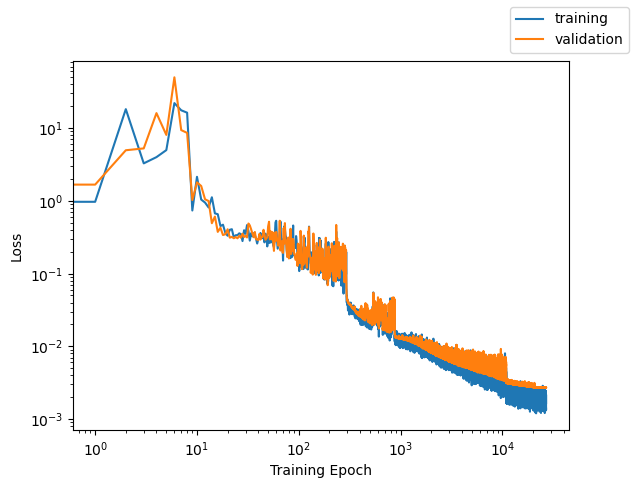

In [20]:
fig, ax=plt.subplots()
ax.plot(all_training_loss, label='training')
ax.plot(all_validation_loss, label='validation', alpha=1)
ax.set_ylabel('Loss')
ax.set_xlabel('Training Epoch')
ax.set_yscale('log')
ax.set_xscale('log')

fig.legend()


### Accuracy on training sample
We can also check how accurate the emulator reproduces the training set. After successful training, this should be a really good accuracy! Otherwise the network might not be learning properly.

In [21]:
# Reading in emulator from file
cp_nn=cosmopower_NN(restore=True, restore_filename=model_filename)

In [22]:
# Getting emulator predictions
emulated_training = np.array(cp_nn.predictions_np(training_parameters))

# Getting relative difference between predictions and actual values
diff=np.abs(emulated_training/train_features_rescaled-1)

# Compute percentiles
percentiles = np.zeros((4, diff.shape[1]))

percentiles[0] = np.percentile(diff, 68, axis = 0)
percentiles[1] = np.percentile(diff, 95, axis = 0)
percentiles[2] = np.percentile(diff, 99, axis = 0)
percentiles[3] = np.percentile(diff, 99.9, axis = 0)

indices_99 = np.argwhere(diff >= percentiles[None, 2])[:,0]



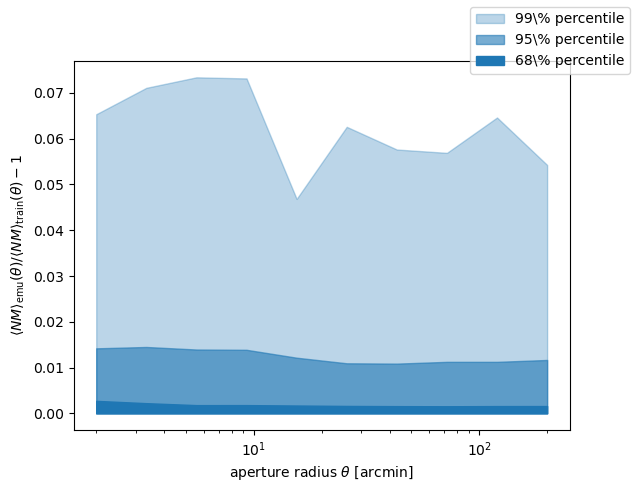

In [23]:
# do plot
fig, ax=plt.subplots()
ax.fill_between(np.rad2deg(modes)*60, 0, percentiles[2,:], color = 'C0', label = r'99\% percentile', alpha=0.3)
ax.fill_between(np.rad2deg(modes)*60, 0, percentiles[1,:], color = 'C0', label = r'95\% percentile', alpha = 0.6)
ax.fill_between(np.rad2deg(modes)*60, 0, percentiles[0,:], color = 'C0', label = r'68\% percentile', alpha = 1)


ax.set_xscale('log')

ax.set_ylabel(r'$\langle N M \rangle_\mathrm{emu}(\theta)/\langle N M \rangle_\mathrm{train}(\theta)-1$')
ax.set_xlabel(r'aperture radius $\theta$ [arcmin]')

fig.legend()


### Accuracy on test sample
The actual test of the emulator though is the accuracy on the test sample (not the validation sample!). This is data the emulator has never seen before, but if has actually learned something, it should perform very well there. 

In [24]:
# Calculating emulated values for testing
emulated_testing = (cp_nn.predictions_np(testing_parameters))


In [25]:
# Getting relative difference between predictions and actual values

diff = np.abs(emulated_testing/test_features_rescaled-1)

# Compute percentiles
percentiles = np.zeros((4, diff.shape[1]))

percentiles[0] = np.percentile(diff, 68, axis = 0)
percentiles[1] = np.percentile(diff, 95, axis = 0)
percentiles[2] = np.percentile(diff, 99, axis = 0)
percentiles[3] = np.percentile(diff, 99.9, axis = 0)

indices_99 = np.argwhere(diff >= percentiles[None, 2])[:,0]


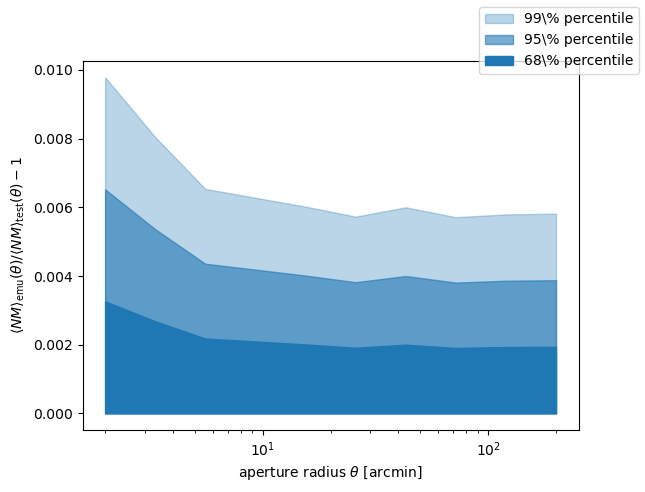

In [26]:
# do plot

fig, ax=plt.subplots()
ax.fill_between(np.rad2deg(modes)*60, 0, percentiles[0,:]*3, color = 'C0', label = r'99\% percentile', alpha=0.3)
ax.fill_between(np.rad2deg(modes)*60, 0, percentiles[0,:]*2, color = 'C0', label = r'95\% percentile', alpha = 0.6)
ax.fill_between(np.rad2deg(modes)*60, 0, percentiles[0,:], color = 'C0', label = r'68\% percentile', alpha = 1)


ax.set_xscale('log')

ax.set_ylabel(r'$\langle N M \rangle_\mathrm{emu}(\theta)/\langle N M \rangle_\mathrm{test}(\theta)-1$')
ax.set_xlabel(r'aperture radius $\theta$ [arcmin]')

fig.legend()
